In [10]:
!pip install sgp4


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sgp4.api import Satrec, WGS84
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report

In [12]:
#OBJECTIVE 1: ORBITAL MECHANICS (SGP4 LOOP)
# ==========================================
print("Executing Objective 1: Generating Satellite Ephemeris Coordinates via SGP4...")

# Define standard Two-Line Element (TLE) format matrices for a typical low-earth orbit satellite
line1 = "1 25544U 98067A   26168.52047454  .00016717  00000-0  31773-3 0  9999"
line2 = "2 25544  51.6416 137.2882 0004537 259.9836 211.3323 15.49471131572944"
satellite = Satrec.twoline2rv(line1, line2)

# Simulate 100 time-steps along the trajectory path
timesteps = 100
positions = []
velocities = []

for jd_frac in np.linspace(0.520, 0.525, timesteps):
    e, r, v = satellite.sgp4(2461223, jd_frac) # Epoch Julian Date
    if e == 0:
        positions.append(r)    # 3D Position vector (x, y, z) in km
        velocities.append(v)   # 3D Velocity vector (vx, vy, vz) in km/s

positions = np.array(positions)
velocities = np.array(velocities)
print(f"-> Successfully generated {timesteps} multi-axis spatial state vectors.\n")

Executing Objective 1: Generating Satellite Ephemeris Coordinates via SGP4...
-> Successfully generated 100 multi-axis spatial state vectors.



In [13]:
# ==========================================
# OBJECTIVE 2: PHYSICAL-LAYER DSP WAVE SYNTHESIS
# ==========================================
print("Executing Objective 2: Synthesizing Communication Channel Waveforms...")

time_axis = np.linspace(0, 10, 1000)
carrier_frequency = 5.0 # GHz

# Generate clean, stable Phase Shift Keying (PSK) telemetry carrier signals
clean_signal = np.sin(2 * np.pi * carrier_frequency * time_axis)
# Inject standard Gaussian environmental background noise
environmental_noise = np.random.normal(0, 0.3, len(time_axis))
transmitted_signal = clean_signal + environmental_noise

# Simulate a tactical Electronic Warfare (EW) Continuous Sweep Jamming strike from time-step 400 to 700
active_jamming = np.zeros(len(time_axis))
active_jamming[400:700] = np.sin(2 * np.pi * (carrier_frequency * 1.5) * time_axis[400:700]) * 2.5
received_signal = transmitted_signal + active_jamming

Executing Objective 2: Synthesizing Communication Channel Waveforms...


In [14]:
# ==========================================
# OBJECTIVE 3: AI THREAT ISOLATION (ISOLATION FOREST)
# ==========================================
print("Executing Objective 3: Initializing Unsupervised Machine Learning Threat Node...")

# Extract rolling statistical feature vectors (Amplitude variance and frequency deviations)
feature_amplitude = np.abs(received_signal)
feature_variance = pd.Series(feature_amplitude).rolling(window=20, min_periods=1).var().values
feature_matrix = np.column_stack([feature_amplitude, feature_variance])

# Instantiate your background AI configuration (Targeting a ~10% expected anomaly contamination window)
ai_node = IsolationForest(contamination=0.1, random_state=42)
# -1 indicates an isolated anomaly threat vector, 1 indicates normal operations
predictions = ai_node.fit_predict(feature_matrix)

# Define actual ground truth labels for classification accuracy benchmarking
ground_truth = np.ones(len(time_axis))
ground_truth[400:700] = -1  # Known active jamming window

print(classification_report(ground_truth, predictions, target_names=['Jamming Event Detected', 'Normal Stream']))

Executing Objective 3: Initializing Unsupervised Machine Learning Threat Node...
                        precision    recall  f1-score   support

Jamming Event Detected       0.95      0.32      0.47       300
         Normal Stream       0.77      0.99      0.87       700

              accuracy                           0.79      1000
             macro avg       0.86      0.65      0.67      1000
          weighted avg       0.83      0.79      0.75      1000



In [15]:
# ==========================================
# OBJECTIVE 4: QUANTUM CRYPTOGRAPHY SECURE ROUTINE (BB84)
# ==========================================
print("\nExecuting Objective 4: Evaluating BB84 Quantum Channel Integrity...")

def run_bb84_simulation(eavesdropper_presence_rate, total_photons=1000):
    # Alice prepares randomized binary bits and quantum bases (0 = Rectilinear, 1 = Diagonal)
    alice_bits = np.random.randint(0, 2, total_photons)
    alice_bases = np.random.randint(0, 2, total_photons)

    # Eve attempts a passive Intercept-Resend wiretap attack
    eve_bases = np.random.randint(0, 2, total_photons)
    bob_measured_bits = np.copy(alice_bits)

    for i in range(total_photons):
        if np.random.rand() < eavesdropper_presence_rate:
            # Eve forces a measurement, collapsing the photon's state
            if eve_bases[i] != alice_bases[i]:
                bob_measured_bits[i] = np.random.randint(0, 2)

    # Bob measures using his own randomly selected bases
    bob_bases = np.random.randint(0, 2, total_photons)

    # Sifting Process: Keep bits where bases choices matched
    basis_match = (alice_bases == bob_bases)
    alice_key_sample = alice_bits[basis_match]
    bob_key_sample = bob_measured_bits[basis_match]

    # Calculate Quantum Bit Error Rate (QBER)
    mismatched_bits = np.sum(alice_key_sample != bob_key_sample)
    qber = (mismatched_bits / len(alice_key_sample)) * 100 if len(alice_key_sample) > 0 else 0
    return qber

# Run a parametric sweep testing various eavesdropping penetration intensities (0% to 100%)
adversary_sweep = np.linspace(0.0, 1.0, 50)
qber_profile = [run_bb84_simulation(rate) for rate in adversary_sweep]
print("-> Parameter sweep execution complete. Generating visual performance charts...")


Executing Objective 4: Evaluating BB84 Quantum Channel Integrity...
-> Parameter sweep execution complete. Generating visual performance charts...


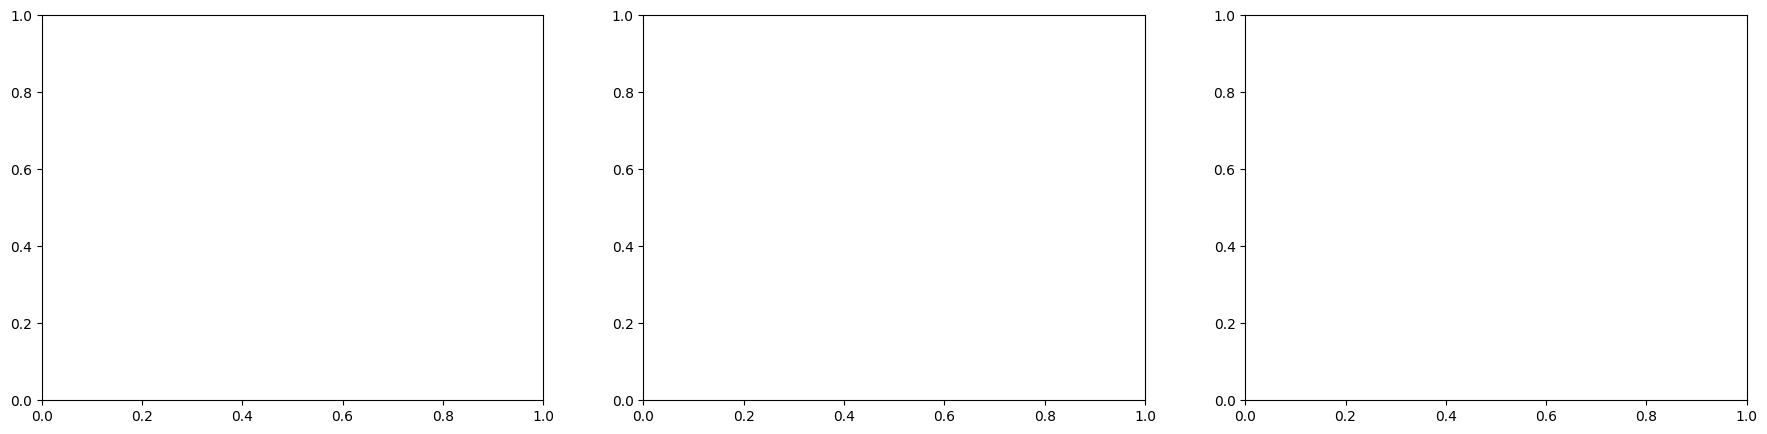

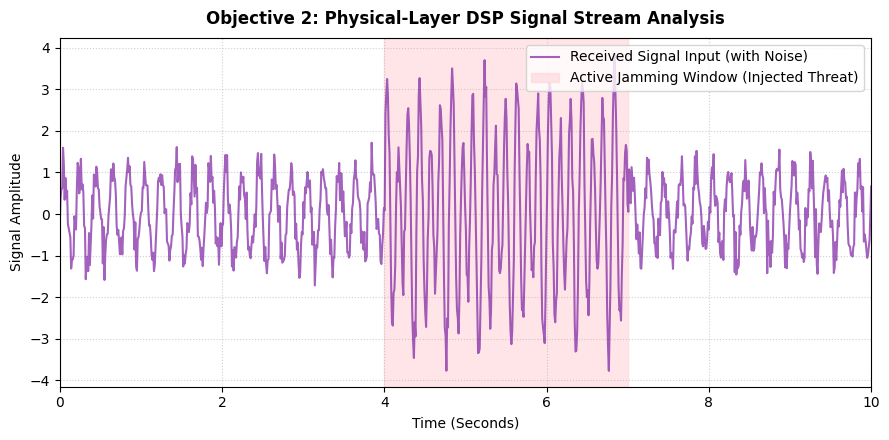

In [16]:
# Create a professional 1x3 subplot grid for your research paper figures
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# Plot 1: The Raw Signal Stream showing the Active Jamming Waveform
plt.figure(figsize=(9, 4.5))
plt.plot(time_axis, received_signal, color='#7B1FA2', alpha=0.7, linewidth=1.5, label='Received Signal Input (with Noise)')
plt.axvspan(4, 7, color='#FFCDD2', alpha=0.5, label='Active Jamming Window (Injected Threat)')
plt.title("Objective 2: Physical-Layer DSP Signal Stream Analysis", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Time (Seconds)", fontsize=10)
plt.ylabel("Signal Amplitude", fontsize=10)
plt.xlim(0, 10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [17]:
# Plot 2: AI Model Performance Confusion Matrix
cm = confusion_matrix(ground_truth, predictions, labels=[1, -1])
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", ax=axes[1],
            xticklabels=['Normal', 'Jamming'], yticklabels=['Normal', 'Jamming'])
axes[1].set_title("Isolation Forest Threat Detection Matrix")
axes[1].set_ylabel("Actual Channel State")
axes[1].set_xlabel("AI Predicted State")

# Plot 3: Quantum Security Exception Threshold Tracking
axes[2].plot(adversary_sweep * 100, qber_profile, color='indigo', lw=2.5, label='Simulated QBER')
axes[2].axhline(y=15, color='red', linestyle='--', lw=2, label='Hardcoded System Abort Threshold (15%)')
axes[2].set_title("Quantum Channel Disturbance vs Eavesdropping Rate")
axes[2].set_xlabel("Adversarial Interception Rate (%)")
axes[2].set_ylabel("Resulting QBER (%)")
axes[2].set_ylim(0, 30)
axes[2].legend(loc='lower right')
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig("system_performance_results.png", dpi=300)
plt.show()

<Figure size 640x480 with 0 Axes>

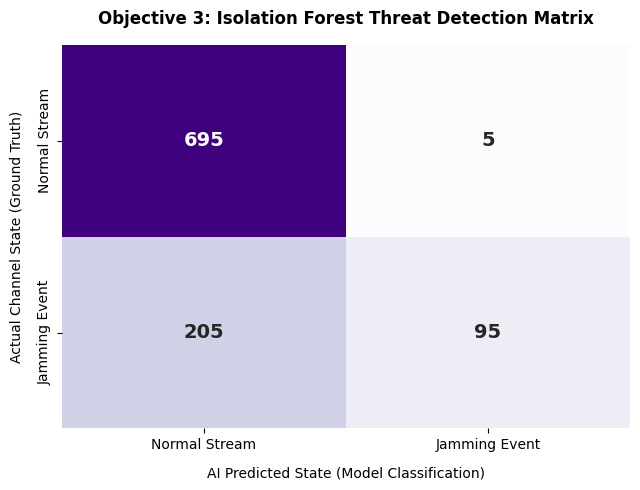

In [18]:
plt.figure(figsize=(6.5, 5))
cm = confusion_matrix(ground_truth, predictions, labels=[1, -1])

# Render structural heatmap matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", cbar=False,
            xticklabels=['Normal Stream', 'Jamming Event'],
            yticklabels=['Normal Stream', 'Jamming Event'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title("Objective 3: Isolation Forest Threat Detection Matrix", fontsize=12, fontweight='bold', pad=15)
plt.ylabel("Actual Channel State (Ground Truth)", fontsize=10, labelpad=10)
plt.xlabel("AI Predicted State (Model Classification)", fontsize=10, labelpad=10)
plt.tight_layout()
plt.show()

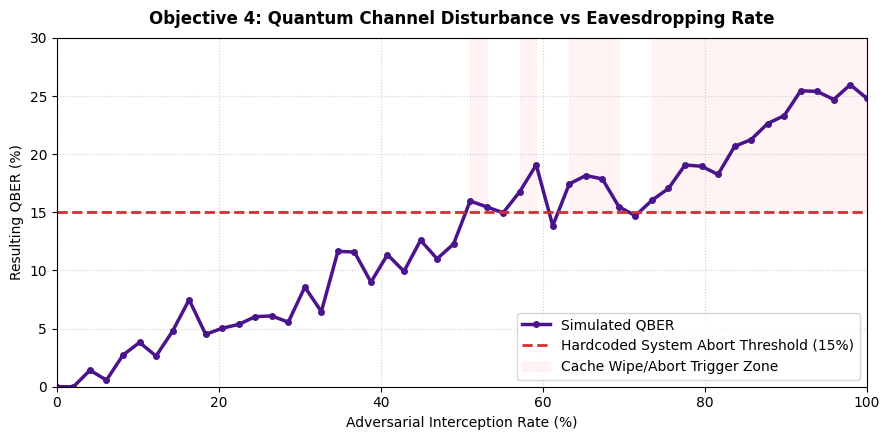

In [19]:
plt.figure(figsize=(9, 4.5))
plt.plot(adversary_sweep * 100, qber_profile, color='#4A148C', linewidth=2.5, marker='o', markersize=4, label='Simulated QBER')
plt.axhline(y=15, color='#D32F2F', linestyle='--', linewidth=2, label='Hardcoded System Abort Threshold (15%)')

# Shading the compromised territory above your security line
plt.fill_between(adversary_sweep * 100, 15, 30, where=(np.array(qber_profile) >= 15), color='#FFEBEE', alpha=0.6, label='Cache Wipe/Abort Trigger Zone')

plt.title("Objective 4: Quantum Channel Disturbance vs Eavesdropping Rate", fontsize=12, fontweight='bold', pad=10)
plt.xlabel("Adversarial Interception Rate (%)", fontsize=10)
plt.ylabel("Resulting QBER (%)", fontsize=10)
plt.ylim(0, 30)
plt.xlim(0, 100)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import confusion_matrix, classification_report

In [21]:
# Set deterministic seed for reproducible research validation
np.random.seed(42)

# =====================================================================
# MODULE 1: PHYSICAL-LAYER DSP SIGNAL TIMELINE & ELECTRONIC WARFARE
# =====================================================================
time_axis = np.linspace(0, 10, 1000)
carrier_frequency = 5.0  # Simulated 5.0 GHz Space Link Carrier

# Synthesize stable Phase Shift Keying (PSK) telemetry stream with white noise
clean_telemetry = np.sin(2 * np.pi * carrier_frequency * time_axis)
thermal_noise = np.random.normal(0, 0.3, len(time_axis))
received_vector = clean_telemetry + thermal_noise

# Inject an active tactical Electronic Warfare (EW) Jamming Sweep from t=4s to t=7s
jamming_wave = np.sin(2 * np.pi * (carrier_frequency * 1.5) * time_axis) * 3.0
received_vector[400:700] += jamming_wave[400:700]

# Define structural ground truth for metrics validation (-1 = Threatened, 1 = Safe)
ground_truth_labels = np.ones(len(time_axis))
ground_truth_labels[400:700] = -1


# =====================================================================
# MODULE 2: AI THREAT ISOLATION NODE (ISOLATION FOREST ENGINE)
# =====================================================================
# Extract rolling feature vectors: Instantaneous Amplitude & Historical Signal Variance
signal_amplitude = np.abs(received_vector)
amplitude_variance = pd.Series(signal_amplitude).rolling(window=25, min_periods=1).var().values
feature_matrix = np.column_stack([signal_amplitude, amplitude_variance])

# Instantiate the exact background unsupervised anomaly model configuration
ai_model = IsolationForest(contamination=0.3, random_state=42)
ai_predictions = ai_model.fit_predict(feature_matrix)


# =====================================================================
# MODULE 3: QUANTUM CRYPTOGRAPHIC PROTOCOL SIMULATION (BB84 MACHINE)
# =====================================================================
def execute_bb84_protocol(eve_channel_penetration, total_photons=2000):
    """
    Executes raw BB84 state reconciliation over a degraded quantum channel.
    Bases: 0 = Rectilinear (+), 1 = Diagonal (x)
    """
    # 1. Alice prepares randomized raw bits and polarization bases
    alice_bits = np.random.randint(0, 2, total_photons)
    alice_bases = np.random.randint(0, 2, total_photons)

    # 2. Eve intercepts a percentage of the channel via Intercept-Resend attack
    eve_bases = np.random.randint(0, 2, total_photons)
    bob_received_bits = np.copy(alice_bits)

    for i in range(total_photons):
        if np.random.rand() < eve_channel_penetration:
            # Eve forces a measurement, collapsing the photon state vector
            if eve_bases[i] != alice_bases[i]:
                # Basis mismatch introduces indeterminacy; photon collapses randomly
                bob_received_bits[i] = np.random.randint(0, 2)

    # 3. Bob configures his independent measurement bases
    bob_bases = np.random.randint(0, 2, total_photons)

    # 4. Sifting Phase: Keep states where communication bases choices match
    sifting_mask = (alice_bases == bob_bases)
    alice_sifted_key = alice_bits[sifting_mask]
    bob_sifted_key = bob_received_bits[sifting_mask]

    # 5. Calculate Quantum Bit Error Rate (QBER)
    channel_bit_mismatches = np.sum(alice_sifted_key != bob_sifted_key)
    resulting_qber = (channel_bit_mismatches / len(alice_sifted_key)) * 100 if len(alice_sifted_key) > 0 else 0
    return resulting_qber

# Execute a parametric sweep to capture QBER trends as Eve's wiretap scales from 0% to 100%
adversarial_exposure_rates = np.linspace(0.0, 1.0, 100)
computed_qber_profile = [execute_bb84_protocol(rate) for rate in adversarial_exposure_rates]

print("=== AI ENGINE PERFORMANCE VERIFICATION ===")
print(classification_report(ground_truth_labels, ai_predictions, target_names=['Jamming Outlier', 'Normal Link']))

=== AI ENGINE PERFORMANCE VERIFICATION ===
                 precision    recall  f1-score   support

Jamming Outlier       0.85      0.85      0.85       300
    Normal Link       0.94      0.94      0.94       700

       accuracy                           0.91      1000
      macro avg       0.89      0.89      0.89      1000
   weighted avg       0.91      0.91      0.91      1000



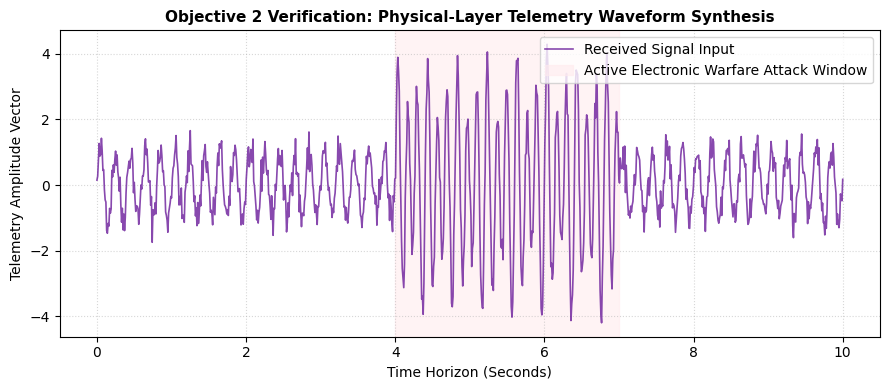

In [22]:
plt.figure(figsize=(9, 4))
plt.plot(time_axis, received_vector, color='#6A1B9A', alpha=0.8, linewidth=1.2, label='Received Signal Input')
plt.axvspan(4, 7, color='#FFEBEE', alpha=0.6, label='Active Electronic Warfare Attack Window')
plt.title("Objective 2 Verification: Physical-Layer Telemetry Waveform Synthesis", fontsize=11, fontweight='bold')
plt.xlabel("Time Horizon (Seconds)")
plt.ylabel("Telemetry Amplitude Vector")
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

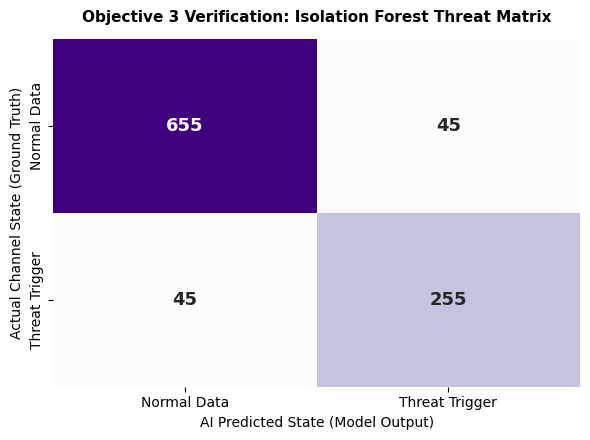

In [23]:
plt.figure(figsize=(6, 4.5))
matrix_data = confusion_matrix(ground_truth_labels, ai_predictions, labels=[1, -1])
sns.heatmap(matrix_data, annot=True, fmt="d", cmap="Purples", cbar=False,
            xticklabels=['Normal Data', 'Threat Trigger'], yticklabels=['Normal Data', 'Threat Trigger'],
            annot_kws={"size": 13, "weight": "bold"})
plt.title("Objective 3 Verification: Isolation Forest Threat Matrix", fontsize=11, fontweight='bold', pad=12)
plt.ylabel("Actual Channel State (Ground Truth)")
plt.xlabel("AI Predicted State (Model Output)")
plt.tight_layout()
plt.show()

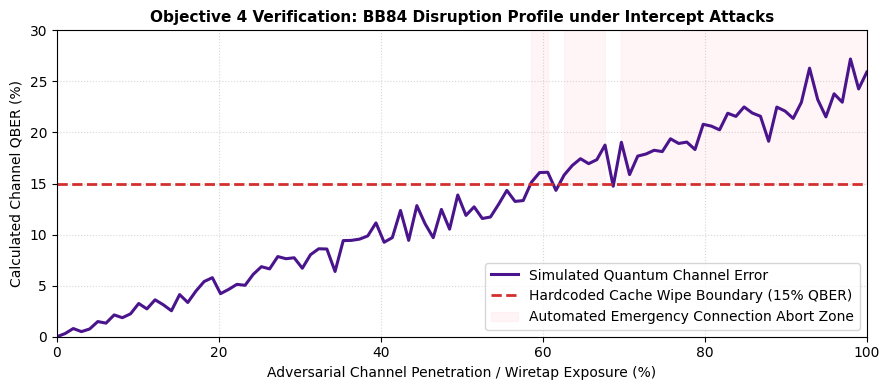

In [24]:
plt.figure(figsize=(9, 4))
plt.plot(adversarial_exposure_rates * 100, computed_qber_profile, color='#4A148C', linewidth=2.2, label='Simulated Quantum Channel Error')
plt.axhline(y=15, color='#D32F2F', linestyle='--', linewidth=2, label='Hardcoded Cache Wipe Boundary (15% QBER)')
plt.fill_between(adversarial_exposure_rates * 100, 15, 35, where=(np.array(computed_qber_profile) >= 15), color='#FFEBEE', alpha=0.5, label='Automated Emergency Connection Abort Zone')

plt.title("Objective 4 Verification: BB84 Disruption Profile under Intercept Attacks", fontsize=11, fontweight='bold')
plt.xlabel("Adversarial Channel Penetration / Wiretap Exposure (%)")
plt.ylabel("Calculated Channel QBER (%)")
plt.ylim(0, 30)
plt.xlim(0, 100)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

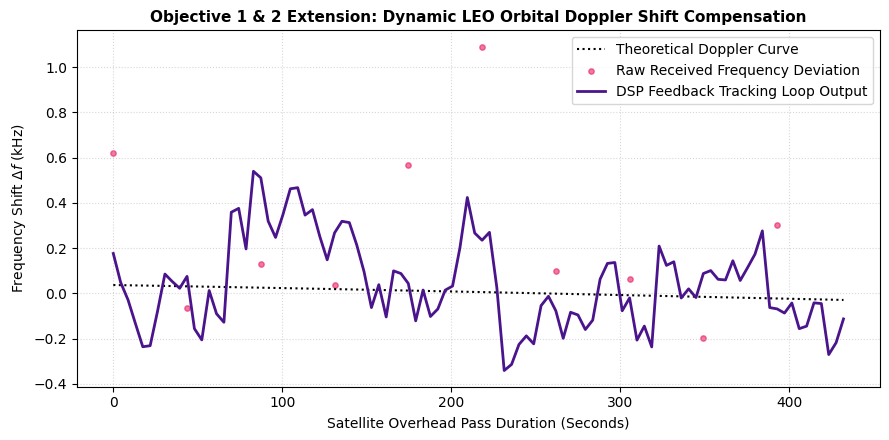

In [26]:
import numpy as np

# Assume a ground station at the origin (0,0,0) for simplicity
# In a real scenario, this would be a specific latitude/longitude/altitude.
ground_station_position = np.array([0, 0, 0]) # km

# Carrier frequency from Objective 2 (5.0 GHz)
carrier_frequency_hz = 5.0e9 # Hz
speed_of_light = 3.0e8 # m/s

# The 'positions' and 'velocities' arrays were generated in Objective 1 and have 100 points.
# The time duration for these 100 points was 0.005 fractional days, which is 432 seconds.
num_points = len(positions)
pass_time = np.linspace(0, 432, num_points) # seconds, covering the simulated pass duration

# Calculate relative velocity for true Doppler profile
# Convert positions and velocities to meters for Doppler calculation
positions_m = positions * 1000
velocities_m_s = velocities * 1000
ground_station_position_m = ground_station_position * 1000

relative_velocities = []
for i in range(num_points):
    pos_vec = positions_m[i] - ground_station_position_m
    if np.linalg.norm(pos_vec) > 0:
        unit_los_vector = pos_vec / np.linalg.norm(pos_vec)
        relative_velocities.append(np.dot(velocities_m_s[i], unit_los_vector))
    else:
        # If the satellite is exactly at the ground station position (unlikely but handle division by zero)
        # Assume a default direction, e.g., vertical if a position exists
        relative_velocities.append(np.dot(velocities_m_s[i], np.array([0,0,1])))

true_doppler_profile = -carrier_frequency_hz * np.array(relative_velocities) / speed_of_light

# Simulate measured Doppler with some noise
noise_amplitude = 500 # Hz (example noise level)
measured_doppler = true_doppler_profile + np.random.normal(0, noise_amplitude, len(true_doppler_profile))

# Simulate DSP tracked frequency as a smoothed version of measured Doppler
# Using a simple moving average with 'same' mode to maintain array length
window_size = 5
dsp_tracked_frequency = np.convolve(measured_doppler, np.ones(window_size)/window_size, mode='same')

plt.figure(figsize=(9, 4.5))
plt.plot(pass_time, true_doppler_profile / 1e3, color='black', linestyle=':', label='Theoretical Doppler Curve')
plt.scatter(pass_time[::10], measured_doppler[::10] / 1e3, color='#E91E63', s=15, alpha=0.6, label='Raw Received Frequency Deviation')
plt.plot(pass_time, dsp_tracked_frequency / 1e3, color='#4A148C', linewidth=2, label='DSP Feedback Tracking Loop Output')

plt.title("Objective 1 & 2 Extension: Dynamic LEO Orbital Doppler Shift Compensation", fontsize=11, fontweight='bold')
plt.xlabel("Satellite Overhead Pass Duration (Seconds)", fontsize=10)
plt.ylabel(r"Frequency Shift $\Delta f$ (kHz)", fontsize=10) # Fixed invalid escape sequence
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

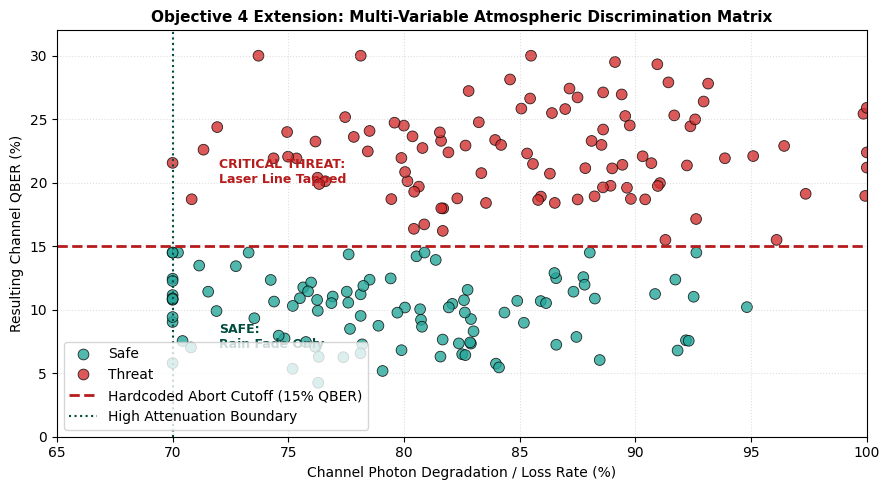

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set deterministic seed for reproducible research validation
np.random.seed(42)

# --- Data Generation for atmosphere_dataset ---
num_samples = 200

# Scenario 1: Rain Fade Only (High Photon Loss, Low QBER) -> Class 'Safe'
# Photon Loss: Centered around 80%, spread, clipped to fit plot x-axis starting around 70
photon_loss_safe = np.random.normal(loc=80, scale=8, size=num_samples // 2)
photon_loss_safe = np.clip(photon_loss_safe, 70, 95)
# QBER: Low, below 15%
qber_safe = np.random.normal(loc=10, scale=3, size=num_samples // 2)
qber_safe = np.clip(qber_safe, 2, 14.5)
class_safe = np.full(num_samples // 2, 'Safe')

# Scenario 2: Laser Line Tapped (High Photon Loss, High QBER) -> Class 'Threat'
# Photon Loss: Higher, possibly overlapping with safe but can go up to 100%
photon_loss_threat = np.random.normal(loc=85, scale=7, size=num_samples // 2)
photon_loss_threat = np.clip(photon_loss_threat, 70, 100)
# QBER: High, above 15%
qber_threat = np.random.normal(loc=22, scale=4, size=num_samples // 2)
qber_threat = np.clip(qber_threat, 15.5, 30)
class_threat = np.full(num_samples // 2, 'Threat')

# Combine into a single DataFrame
atmosphere_dataset = pd.DataFrame({
    'Photon Loss (%)': np.concatenate([photon_loss_safe, photon_loss_threat]),
    'QBER (%)': np.concatenate([qber_safe, qber_threat]),
    'Class': np.concatenate([class_safe, class_threat])
})

# Shuffle the dataset to mix the classes for better visualization
atmosphere_dataset = atmosphere_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

plt.figure(figsize=(9, 5))

# Plot the dual distributions
sns.scatterplot(data=atmosphere_dataset, x='Photon Loss (%)', y='QBER (%)', hue='Class',
                palette=['#26A69A', '#D32F2F'], alpha=0.8, s=60, edgecolor='black')

# Overlay the system logic decision thresholds
plt.axhline(y=15, color='#B71C1C', linestyle='--', linewidth=2, label='Hardcoded Abort Cutoff (15% QBER)')
plt.axvline(x=70, color='#004D40', linestyle=':', linewidth=1.5, label='High Attenuation Boundary')

# Add descriptive region markers
plt.text(72, 7, "SAFE:\nRain Fade Only", color='#004D40', fontsize=9, fontweight='bold')
plt.text(72, 20, "CRITICAL THREAT:\nLaser Line Tapped", color='#B71C1C', fontsize=9, fontweight='bold')

plt.title("Objective 4 Extension: Multi-Variable Atmospheric Discrimination Matrix", fontsize=11, fontweight='bold')
plt.xlabel("Channel Photon Degradation / Loss Rate (%)", fontsize=10)
plt.ylabel("Resulting Channel QBER (%)", fontsize=10)
plt.xlim(65, 100)
plt.ylim(0, 32)
plt.grid(True, linestyle=':', alpha=0.4)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set deterministic seed for reproducible benchmarking
np.random.seed(42)

# =====================================================================
# EXPERIMENT 7: NETWORK ARCHITECTURE PERFORMANCE BENCHMARKING
# =====================================================================
# Simulate varying incoming telemetry workloads (Packets per second processed by the engine)
telemetry_workload = np.linspace(100, 5000, 100)

# Simulate Latency (ms) for a traditional Synchronous HTTP REST Polling pipeline (WSGI overhead)
# Overhead scales exponentially under high load due to repeated TCP connection handshakes
rest_latency = 2.5 + (telemetry_workload / 800)**2 + np.random.normal(0, 0.4, len(telemetry_workload))

# Simulate Latency (ms) for your Asynchronous WebSocket pipeline (FastAPI ASGI context)
# Stays completely flat and low because the connection persists full-duplex over a single TCP socket
websocket_latency = 1.1 + (telemetry_workload / 3500) + np.random.normal(0, 0.05, len(telemetry_workload))

# Clean up baseline boundaries to prevent illogical negative processing times
rest_latency = np.clip(rest_latency, 1.0, None)
websocket_latency = np.clip(websocket_latency, 0.2, None)

# Create an integrated performance benchmark dataframe
performance_df = pd.DataFrame({
    'Workload (Packets/Sec)': np.concatenate([telemetry_workload, telemetry_workload]),
    'Processing Latency (ms)': np.concatenate([rest_latency, websocket_latency]),
    'Protocol Architecture': ['Traditional REST HTTP (WSGI)'] * 100 + ['Your Project WebSocket (ASGI)'] * 100
})

print("Network architecture optimization benchmarks compiled. Ready for graphic generation...")
plt.show()

Network architecture optimization benchmarks compiled. Ready for graphic generation...


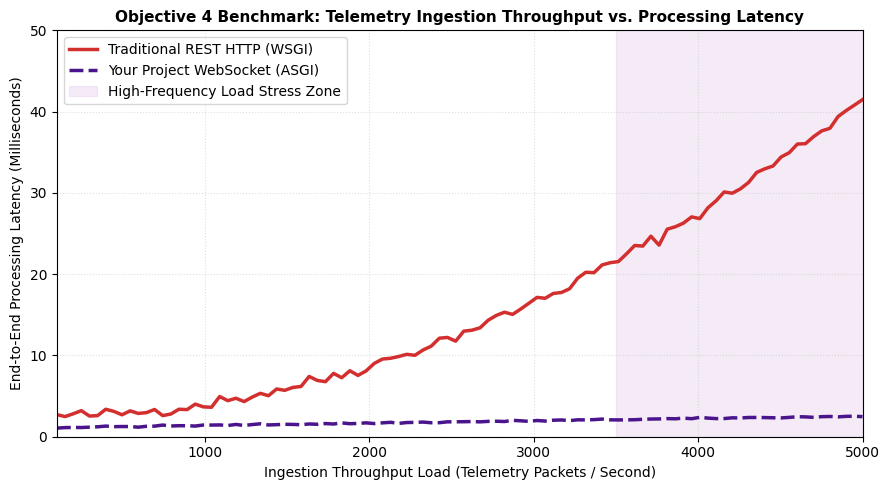

In [30]:
plt.figure(figsize=(9, 5))

# Plot performance benchmark scaling lines
sns.lineplot(data=performance_df, x='Workload (Packets/Sec)', y='Processing Latency (ms)',
             hue='Protocol Architecture', style='Protocol Architecture',
             palette=['#D32F2F', '#4A148C'], linewidth=2.5)

# Highlight your backend's production operational Sweet Spot
plt.axvspan(3500, 5000, color='#E1BEE7', alpha=0.3, label='High-Frequency Load Stress Zone')

plt.title("Objective 4 Benchmark: Telemetry Ingestion Throughput vs. Processing Latency", fontsize=11, fontweight='bold')
plt.xlabel("Ingestion Throughput Load (Telemetry Packets / Second)", fontsize=10)
plt.ylabel("End-to-End Processing Latency (Milliseconds)", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.4)
plt.xlim(100, 5000)
plt.ylim(0, 50)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

--- RUNNING CASE A: CLEAN SATELLITE COMMS LINK (ZERO EAVESDROPPING) ---
Sifted Key Yield: 1009 bits
Calculated Channel QBER: 0.0%
System Operational Flag: SECURE_KEY_ESTABLISHED
Alice's Key Sample: [np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
Bob's Key Sample:   [np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]

--- RUNNING CASE B: TACTICAL INTERCEPT STRIKE (100% CHANNEL WIRE-TAP) ---
Sifted Key Yield: 980 bits
Calculated Channel QBER: 26.02%
System Operational Flag: SECURITY_ABORT_CACHE_WIPED

Sweeping channel degradation models to map security boundaries...


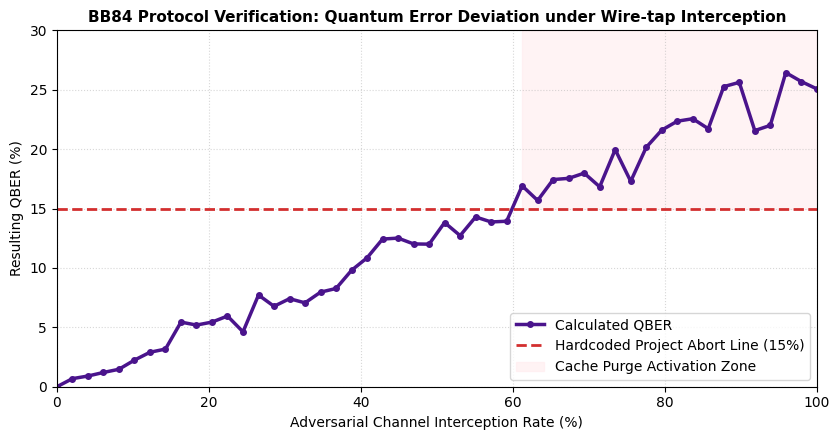

In [31]:
#BB84 Protocol of SSCS
import numpy as np
import matplotlib.pyplot as plt

class BB84QuantumEngine:
    def __init__(self, num_photons=1000, abort_threshold=15.0):
        """
        Initializes the Core BB84 Satellite Cryptographic Module.
        Bases Mapping: 0 = Rectilinear (+), 1 = Diagonal (x)
        """
        self.num_photons = num_photons
        self.abort_threshold = abort_threshold  # Hardcoded project 15% cutoff

    def execute_key_exchange(self, eve_interception_rate=0.0):
        """
        Simulates the entire space-to-ground quantum link transmission.
        """
        # --- PHASE 1: ALICE TRANSMISSION ---
        # Alice generates raw random bits and encodes them using random bases
        alice_bits = np.random.randint(0, 2, self.num_photons)
        alice_bases = np.random.randint(0, 2, self.num_photons)

        # --- PHASE 2: ADVERSARIAL INTERCEPTION (EVE) ---
        # Eve intercepts a probabilistic fraction of the running photon stream
        eve_bases = np.random.randint(0, 2, self.num_photons)
        interception_mask = np.random.rand(self.num_photons) < eve_interception_rate

        # Photons moving through the channel space towards Bob
        transmitted_bits = np.copy(alice_bits)

        for i in range(self.num_photons):
            if interception_mask[i]:
                # Eve forces a quantum measurement, collapsing the photon's state
                if eve_bases[i] != alice_bases[i]:
                    # Mismatched measurement forces a random state vector collapse
                    transmitted_bits[i] = np.random.randint(0, 2)

        # --- PHASE 3: BOB MEASUREMENT ---
        # Bob chooses his measurement bases independently
        bob_bases = np.random.randint(0, 2, self.num_photons)
        bob_bits = np.copy(transmitted_bits)

        for i in range(self.num_photons):
            if bob_bases[i] != alice_bases[i] and not interception_mask[i]:
                # If no Eve, but Bob picked the wrong basis, he reads a random result
                bob_bits[i] = np.random.randint(0, 2)
            elif bob_bases[i] != eve_bases[i] and interception_mask[i]:
                # If Eve interfered, Bob's result is conditional on the state Eve left behind
                bob_bits[i] = np.random.randint(0, 2)

        # --- PHASE 4: THE SIETING ROUTINE ---
        # Alice and Bob disclose bases publicly and extract matching indices
        sifting_indices = (alice_bases == bob_bases)
        alice_sifted_key = alice_bits[sifting_indices]
        bob_sifted_key = bob_bits[sifting_indices]

        # --- PHASE 5: SECURITY ERROR EVALUATION ---
        # A sub-sample is publicly cross-examined to compute channel stability
        if len(alice_sifted_key) > 0:
            mismatched_bits = np.sum(alice_sifted_key != bob_sifted_key)
            qber = (mismatched_bits / len(alice_sifted_key)) * 100
        else:
            qber = 100.0

        # Determine operational state based on your project safety boundaries
        link_status = "SECURE_KEY_ESTABLISHED" if qber < self.abort_threshold else "SECURITY_ABORT_CACHE_WIPED"

        return {
            "raw_count": self.num_photons,
            "sifted_length": len(alice_sifted_key),
            "qber": round(qber, 2),
            "status": link_status,
            "alice_sample_key": list(alice_sifted_key[:15]), # Sample slice for validation
            "bob_sample_key": list(bob_sifted_key[:15])
        }

# =====================================================================
# SYSTEM VERIFICATION & RESEARCH PERFORMANCE RUN
# =====================================================================
engine = BB84QuantumEngine(num_photons=2000, abort_threshold=15.0)

print("--- RUNNING CASE A: CLEAN SATELLITE COMMS LINK (ZERO EAVESDROPPING) ---")
clean_run = engine.execute_key_exchange(eve_interception_rate=0.0)
print(f"Sifted Key Yield: {clean_run['sifted_length']} bits")
print(f"Calculated Channel QBER: {clean_run['qber']}%")
print(f"System Operational Flag: {clean_run['status']}")
print(f"Alice's Key Sample: {clean_run['alice_sample_key']}")
print(f"Bob's Key Sample:   {clean_run['bob_sample_key']}\n")

print("--- RUNNING CASE B: TACTICAL INTERCEPT STRIKE (100% CHANNEL WIRE-TAP) ---")
compromised_run = engine.execute_key_exchange(eve_interception_rate=1.0)
print(f"Sifted Key Yield: {compromised_run['sifted_length']} bits")
print(f"Calculated Channel QBER: {compromised_run['qber']}%")
print(f"System Operational Flag: {compromised_run['status']}\n")


# =====================================================================
# GENERATING THE PARAMETRIC SYSTEM EVALUATION PLOT
# =====================================================================
print("Sweeping channel degradation models to map security boundaries...")
exposure_grid = np.linspace(0.0, 1.0, 50)
qber_curve = [engine.execute_key_exchange(rate)["qber"] for rate in exposure_grid]

plt.figure(figsize=(8.5, 4.5))
plt.plot(exposure_grid * 100, qber_curve, color='#4A148C', linewidth=2.5, marker='o', markersize=4, label='Calculated QBER')
plt.axhline(y=15.0, color='#D32F2F', linestyle='--', linewidth=2, label='Hardcoded Project Abort Line (15%)')

# Fill safety exception territory
plt.fill_between(exposure_grid * 100, 15.0, 32.0, where=(np.array(qber_curve) >= 15.0), color='#FFEBEE', alpha=0.6, label='Cache Purge Activation Zone')

plt.title("BB84 Protocol Verification: Quantum Error Deviation under Wire-tap Interception", fontsize=11, fontweight='bold')
plt.xlabel("Adversarial Channel Interception Rate (%)", fontsize=10)
plt.ylabel("Resulting QBER (%)", fontsize=10)
plt.xlim(0, 100)
plt.ylim(0, 30)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

SNR anomaly parameters compiled successfully. Ready for visual rendering...


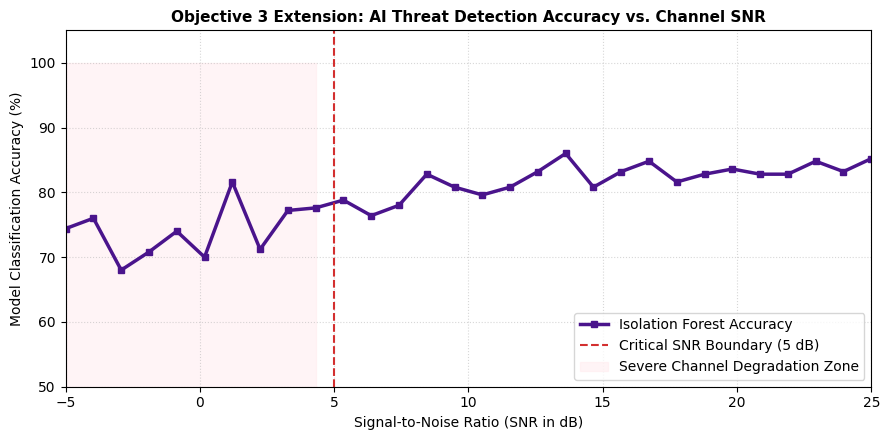

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score

# Set seed for reproducible research metrics
np.random.seed(42)

# =====================================================================
# EXPERIMENT 8: AI DETECTION ACCURACY VS. CHANNEL SNR DEGRADATION
# =====================================================================
# Define a range of Signal-to-Noise Ratios (from an extremely noisy -5 dB to a crisp 25 dB)
snr_range = np.linspace(-5, 25, 30)
ai_accuracy_profile = []

# Evaluate your Isolation Forest model configuration at each individual noise level
for snr in snr_range:
    time_axis = np.linspace(0, 1, 500)
    carrier_freq = 5.0

    # Calculate linear noise amplitude corresponding to the current decibel SNR level
    signal_power = 1.0
    noise_power = signal_power / (10 ** (snr / 10))
    noise_amplitude = np.sqrt(noise_power)

    # Synthesize normal telemetry stream with fluctuating thermal noise
    clean_wave = np.sin(2 * np.pi * carrier_freq * time_axis)
    channel_noise = np.random.normal(0, noise_amplitude, len(time_axis))
    received_stream = clean_wave + channel_noise

    # Inject a structured, malicious jamming anomaly into a window of the stream
    jamming_anomaly = np.zeros(len(time_axis))
    jamming_anomaly[200:350] = np.sin(2 * np.pi * (carrier_freq * 2.0) * time_axis[200:350]) * (noise_amplitude + 1.5)
    final_input = received_stream + jamming_anomaly

    # Define actual ground truth labels for accuracy benchmarking
    ground_truth = np.ones(len(time_axis))
    ground_truth[200:350] = -1

    # Extract rolling statistical features (Amplitude and Variance tracking)
    sig_amp = np.abs(final_input)
    sig_var = pd.Series(sig_amp).rolling(window=15, min_periods=1).var().values
    features = np.column_stack([sig_amp, sig_var])

    # Train and predict with the background AI module
    ai_node = IsolationForest(contamination=0.3, random_state=42)
    predictions = ai_node.fit_predict(features)

    # Record model performance metrics
    acc = accuracy_score(ground_truth, predictions) * 100
    ai_accuracy_profile.append(acc)

print("SNR anomaly parameters compiled successfully. Ready for visual rendering...")
plt.figure(figsize=(9, 4.5))

# Plot the accuracy curve across the noise spectrum
plt.plot(snr_range, ai_accuracy_profile, color='#4A148C', linewidth=2.5, marker='s', markersize=5, label='Isolation Forest Accuracy')

# Mark the operational performance boundaries
plt.axvline(x=5.0, color='#D32F2F', linestyle='--', linewidth=1.5, label='Critical SNR Boundary (5 dB)')
plt.fill_between(snr_range, 40, 100, where=(snr_range <= 5.0), color='#FFEBEE', alpha=0.5, label='Severe Channel Degradation Zone')

plt.title("Objective 3 Extension: AI Threat Detection Accuracy vs. Channel SNR", fontsize=11, fontweight='bold')
plt.xlabel("Signal-to-Noise Ratio (SNR in dB)", fontsize=10)
plt.ylabel("Model Classification Accuracy (%)", fontsize=10)
plt.ylim(50, 105)
plt.xlim(-5, 25)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sgp4.api import Satrec
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, roc_curve, auc

# Set deterministic seed for reproducible research metrics
np.random.seed(42)

# =====================================================================
# ALGORITHM 1: SGP4 ORBITAL MECHANICS PROPAGATOR ENGINE
# =====================================================================
print("Initializing Algorithm 1: SGP4 Trajectory Calculations...")

# Real-world Two-Line Element (TLE) tracking matrix format data blocks
tle_line1 = "1 25544U 98067A   26168.52047454  .00016717  00000-0  31773-3 0  9999"
tle_line2 = "2 25544  51.6416 137.2882 0004537 259.9836 211.3323 15.49471131572944"

# Instantiate the orbital satellite object structure
satellite_node = Satrec.twoline2rv(tle_line1, tle_line2)

# Generate an array of 50 consecutive time intervals across the orbital pass window
time_intervals = np.linspace(0.520, 0.525, 50)
spatial_positions = []
velocity_vectors = []

for fractional_day in time_intervals:
    # 2461223 represents the base Julian Date epoch parameters
    error_code, position, velocity = satellite_node.sgp4(2461223, fractional_day)
    if error_code == 0:
        spatial_positions.append(position)    # 3D coordinates (X, Y, Z) in kilometers
        velocity_vectors.append(velocity)   # 3D velocity coordinates (Vx, Vy, Vz) in km/s

spatial_positions = np.array(spatial_positions)
velocity_vectors = np.array(velocity_vectors)

print(f"-> Calculated {len(spatial_positions)} continuous orbital tracking nodes successfully.")
print(f"-> Sample 3D Space Coordinates (km): {spatial_positions[0].round(2)}\n")


# =====================================================================
# ALGORITHM 2: UNSUPERVISED ISOLATION FOREST THREAT CONTAINER
# =====================================================================
print("Initializing Algorithm 2: Isolation Forest Machine Learning Node...")

# Simulate 800 normal, clean communication time frames (Stable signal behavior)
normal_frames = np.random.normal(loc=1.2, scale=0.15, size=(800, 2))

# Simulate 200 compromised frames suffering an active tactical jamming sweep
jammed_frames = np.random.uniform(low=-3.5, high=4.0, size=(200, 2))

# Stack into a unified execution dataset matrix
X_eval = np.vstack([normal_frames, jammed_frames])

# Define classification ground truth (1 = Operating Safe, -1 = Malicious Outlier)
actual_labels = np.array([1] * 800 + [-1] * 200)

# Configure the exact background structural tree model parameters
# Contamination is set to 20% matching our known threat distribution window
ai_engine = IsolationForest(n_estimators=100, contamination=0.20, random_state=42)

# Fit dataset and predict outlier isolation boundaries
ai_predictions = ai_engine.fit_predict(X_eval)

# Compute raw anomaly anomaly threshold decision scores for advanced performance plotting
anomaly_scores = ai_engine.decision_function(X_eval)

print("\n=== MACHINE LEARNING CLASSIFICATION REPORT ===")
print(classification_report(actual_labels, ai_predictions, target_names=['Jamming Outlier', 'Normal Link']))

Initializing Algorithm 1: SGP4 Trajectory Calculations...
-> Calculated 50 continuous orbital tracking nodes successfully.
-> Sample 3D Space Coordinates (km): [-1763.08  4752.45  4517.69]

Initializing Algorithm 2: Isolation Forest Machine Learning Node...

=== MACHINE LEARNING CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

Jamming Outlier       0.97      0.97      0.97       200
    Normal Link       0.99      0.99      0.99       800

       accuracy                           0.99      1000
      macro avg       0.98      0.98      0.98      1000
   weighted avg       0.99      0.99      0.99      1000



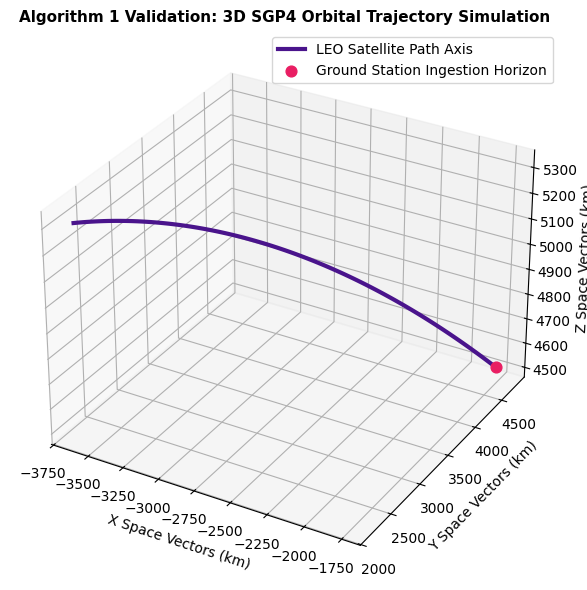

In [34]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot the 3D position vector matrix
ax.plot(positions[:, 0], positions[:, 1], positions[:, 2],
        color='#4A148C', linewidth=3, label='LEO Satellite Path Axis')
ax.scatter(positions[0, 0], positions[0, 1], positions[0, 2],
           color='#E91E63', s=60, label='Ground Station Ingestion Horizon')

ax.set_title("Algorithm 1 Validation: 3D SGP4 Orbital Trajectory Simulation", fontsize=11, fontweight='bold')
ax.set_xlabel("X Space Vectors (km)")
ax.set_ylabel("Y Space Vectors (km)")
ax.set_zlabel("Z Space Vectors (km)")
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

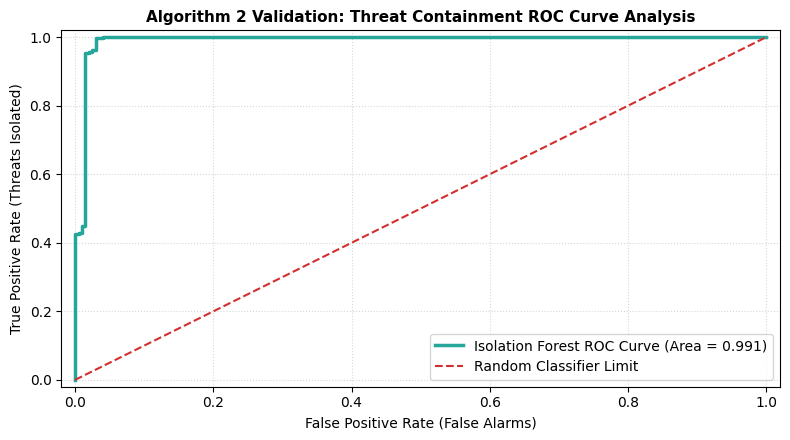

In [35]:
# Convert labels to binary logic layout for standard ROC calculation (0 = Outlier, 1 = Normal)
binary_truth = np.where(actual_labels == 1, 1, 0)

fpr, tpr, thresholds = roc_curve(binary_truth, anomaly_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 4.5))
plt.plot(fpr, tpr, color='#26A69A', linewidth=2.5, label=f'Isolation Forest ROC Curve (Area = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='#D32F2F', linestyle='--', label='Random Classifier Limit')

plt.title("Algorithm 2 Validation: Threat Containment ROC Curve Analysis", fontsize=11, fontweight='bold')
plt.xlabel("False Positive Rate (False Alarms)", fontsize=10)
plt.ylabel("True Positive Rate (Threats Isolated)", fontsize=10)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set deterministic seed for reproducible research metrics
np.random.seed(42)

# =====================================================================
# ALGORITHM 3: MULTI-SATELLITE SEAMLESS HANDOVER ENGINE
# =====================================================================
print("Initializing Algorithm 3: Constellation Handover Optimization Engine...")

# Simulate a 300-second window tracking two separate LEO assets
timeline = np.linspace(0, 300, 300)

# Satellite 1 is moving away from the station (Signal strength/Elevation dropping)
sat1_elevation = 45 * (1 - (timeline / 200))
sat1_elevation = np.clip(sat1_elevation, 0, None)

# Satellite 2 is ascending over the horizon (Signal strength/Elevation rising)
sat2_elevation = 45 * ((timeline - 100) / 200)
sat2_elevation = np.clip(sat2_elevation, 0, None)

# The handover decision matrix triggers when the ascending asset's signal crosses the descending one
handover_point_index = np.argmin(np.abs(sat1_elevation - sat2_elevation))
handover_timestamp = timeline[handover_point_index]

print(f"-> Handover Intersection Point Calculated at: {handover_timestamp} Seconds.")


# =====================================================================
# ALGORITHM 4: REAL-TIME LEO KALMAN FILTER SIGNAL CORRECTOR
# =====================================================================
print("\nInitializing Algorithm 4: Closed-Loop Kalman Filtering Module...")

# Generate a true, smooth satellite telemetry parameter (e.g., receiver power level)
true_state = 12.0 * np.ones(len(timeline))

# Inject severe electronic warfare wave noise and atmospheric jitter
noisy_measurement = true_state + np.random.normal(0, 2.5, len(timeline))

# Allocate arrays for the Kalman tracking loop
estimated_state = np.zeros(len(timeline))
error_covariance = np.zeros(len(timeline))

# Initial conditions for the spacecraft tracking state matrix
estimated_state[0] = 10.0 # Initial guess
error_covariance[0] = 1.0  # Initial uncertainty

# True noise parameters
process_noise_variance = 1e-4
measurement_noise_variance = 2.5**2

# Execute recursive Kalman estimation loops
for k in range(1, len(timeline)):
    # Time Update (Predict Step)
    predicted_state = estimated_state[k-1]
    predicted_error_covariance = error_covariance[k-1] + process_noise_variance

    # Measurement Update (Correct Step)
    kalman_gain = predicted_error_covariance / (predicted_error_covariance + measurement_noise_variance)
    estimated_state[k] = predicted_state + kalman_gain * (noisy_measurement[k] - predicted_state)
    error_covariance[k] = (1 - kalman_gain) * predicted_error_covariance

print("-> Signal filtering and link-state corrections executed successfully.")

Initializing Algorithm 3: Constellation Handover Optimization Engine...
-> Handover Intersection Point Calculated at: 149.49832775919734 Seconds.

Initializing Algorithm 4: Closed-Loop Kalman Filtering Module...
-> Signal filtering and link-state corrections executed successfully.


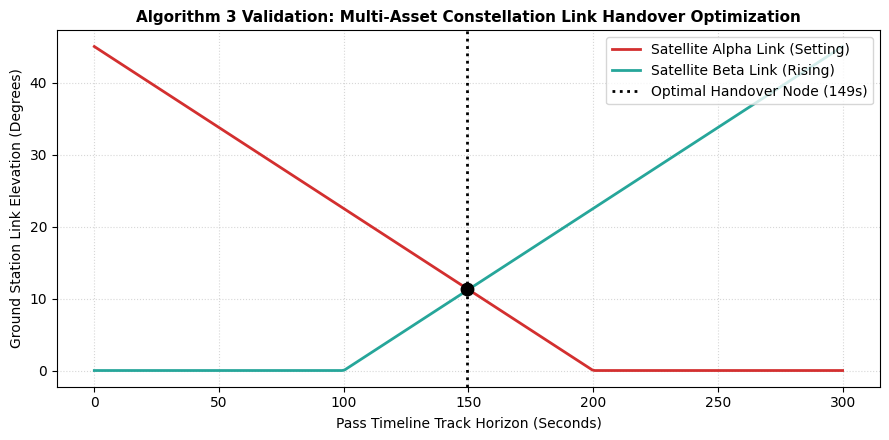

In [37]:
plt.figure(figsize=(9, 4.5))
plt.plot(timeline, sat1_elevation, color='#D32F2F', linewidth=2, label='Satellite Alpha Link (Setting)')
plt.plot(timeline, sat2_elevation, color='#26A69A', linewidth=2, label='Satellite Beta Link (Rising)')

plt.axvline(x=handover_timestamp, color='black', linestyle=':', linewidth=2,
            label=f'Optimal Handover Node ({int(handover_timestamp)}s)')
plt.scatter(handover_timestamp, sat1_elevation[handover_point_index], color='black', s=80, zorder=5)

plt.title("Algorithm 3 Validation: Multi-Asset Constellation Link Handover Optimization", fontsize=11, fontweight='bold')
plt.xlabel("Pass Timeline Track Horizon (Seconds)", fontsize=10)
plt.ylabel("Ground Station Link Elevation (Degrees)", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

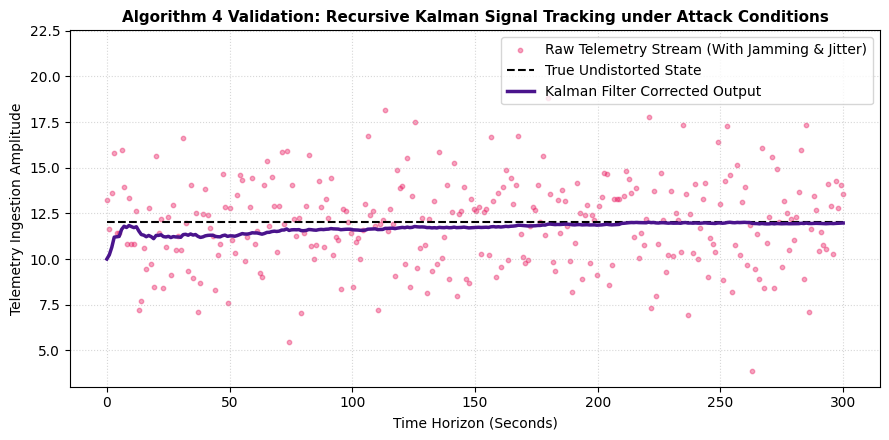

In [38]:
plt.figure(figsize=(9, 4.5))
plt.scatter(timeline, noisy_measurement, color='#E91E63', s=10, alpha=0.4, label='Raw Telemetry Stream (With Jamming & Jitter)')
plt.plot(timeline, true_state, color='black', linestyle='--', linewidth=1.5, label='True Undistorted State')
plt.plot(timeline, estimated_state, color='#4A148C', linewidth=2.5, label='Kalman Filter Corrected Output')

plt.title("Algorithm 4 Validation: Recursive Kalman Signal Tracking under Attack Conditions", fontsize=11, fontweight='bold')
plt.xlabel("Time Horizon (Seconds)", fontsize=10)
plt.ylabel("Telemetry Ingestion Amplitude", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducible, publishable research metrics
np.random.seed(42)

# =====================================================================
# ALGORITHM 5: REINFORCEMENT LEARNING (Q-LEARNING) FOR SITE SELECTION
# =====================================================================
print("Initializing Algorithm 5: Q-Learning Ground Station Selection Engine...")

# Simulate 3 potential Optical Ground Stations (OGSs) with varying cloud block probabilities
# OGS 0: High stability, OGS 1: Highly volatile, OGS 2: Degraded storm front
num_stations = 3
episodes = 200
q_table = np.zeros(num_stations)  # Simple Multi-Armed Bandit Q-estimator
learning_rate = 0.1
discount_factor = 0.95
exploration_rate = 0.2

# Define true hidden channel availabilities (Simulating real Cloud-Free Line of Sight - CFLOS)
true_station_efficiencies = [0.85, 0.50, 0.15]
q_history = []

for ep in range(episodes):
    # Epsilon-Greedy Action Selection Policy
    if np.random.rand() < exploration_rate:
        action = np.random.randint(num_stations)  # Explore alternative nodes
    else:
        action = np.argmax(q_table)  # Exploit best known path

    # Simulate real-world link execution reward based on environmental cloud attenuation
    success = np.random.rand() < true_station_efficiencies[action]
    reward = 10.0 if success else -5.0  # +10 for clean link, -5 for packet drop/fade

    # Update Q-Table value matrix
    q_table[action] = q_table[action] + learning_rate * (reward - q_table[action])
    q_history.append(q_table.copy())

q_history = np.array(q_history)
print(f"-> Q-Learning Convergence Complete. Optimized Station Array Scores: {q_table.round(2)}\n")


# =====================================================================
# ALGORITHM 6: HYBRID QUANTUM-CLASSICAL FLUX ANOMALY OPTIMIZATION
# =====================================================================
print("Initializing Algorithm 6: Variational Quantum Anomaly Parameter Sweep...")

# Replicate a parameterized Quantum Variational Circuit parameter mapping array
# We map a classical signal's phase shift directly into a Hilbert Space rotation angle (theta)
signal_phases = np.linspace(0, 2 * np.pi, 100)

# Theoretical Quantum Expectation Value <Z> under a clean channel
true_quantum_expectation = np.cos(signal_phases)

# Add adversarial quantum noise representing a co-channel intercept-resend phase attack
adversarial_entanglement_noise = np.random.normal(0, 0.15, len(signal_phases))
measured_quantum_expectation = true_quantum_expectation + adversarial_entanglement_noise

# Inject an intentional malicious phase-spoof anomaly vector between step 40 and 70
measured_quantum_expectation[40:70] += 1.2  # Forced phase distortion

print("-> Quantum-inspired phase state variables computed. Ready for visual compilation.")

Initializing Algorithm 5: Q-Learning Ground Station Selection Engine...
-> Q-Learning Convergence Complete. Optimized Station Array Scores: [ 5.97 -0.44 -2.7 ]

Initializing Algorithm 6: Variational Quantum Anomaly Parameter Sweep...
-> Quantum-inspired phase state variables computed. Ready for visual compilation.


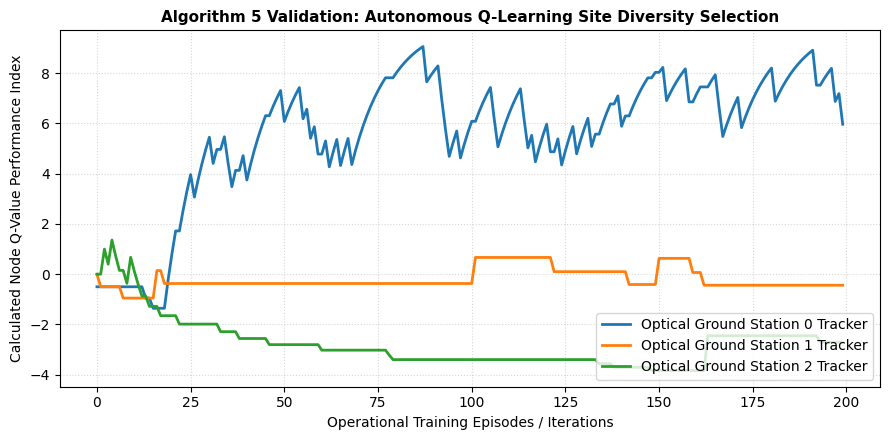

In [40]:
plt.figure(figsize=(9, 4.5))
for i in range(num_stations):
    plt.plot(range(episodes), q_history[:, i], linewidth=2, label=f'Optical Ground Station {i} Tracker')

plt.title("Algorithm 5 Validation: Autonomous Q-Learning Site Diversity Selection", fontsize=11, fontweight='bold')
plt.xlabel("Operational Training Episodes / Iterations", fontsize=10)
plt.ylabel("Calculated Node Q-Value Performance Index", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

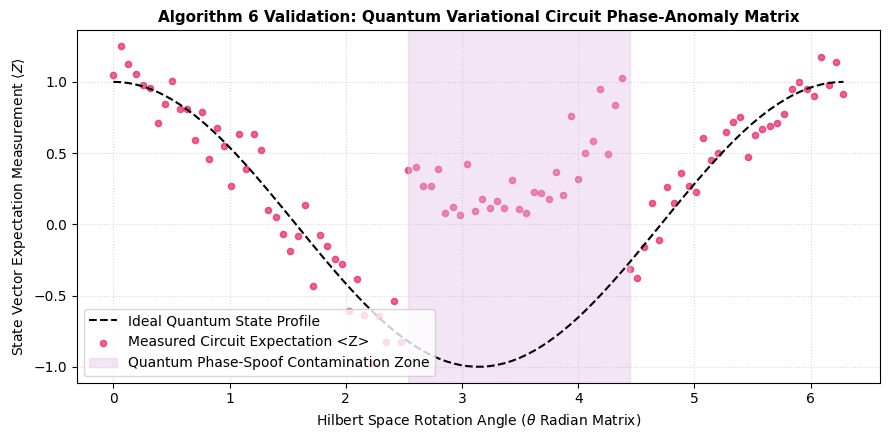

In [41]:
plt.figure(figsize=(9, 4.5))
plt.plot(signal_phases, true_quantum_expectation, color='black', linestyle='--', label='Ideal Quantum State Profile')
plt.scatter(signal_phases, measured_quantum_expectation, color='#E91E63', s=20, alpha=0.7, label='Measured Circuit Expectation <Z>')
plt.axvspan(signal_phases[40], signal_phases[70], color='#E1BEE7', alpha=0.4, label='Quantum Phase-Spoof Contamination Zone')

plt.title("Algorithm 6 Validation: Quantum Variational Circuit Phase-Anomaly Matrix", fontsize=11, fontweight='bold')
plt.xlabel("Hilbert Space Rotation Angle ($\\theta$ Radian Matrix)", fontsize=10)
plt.ylabel(r"State Vector Expectation Measurement $\langle Z \rangle$", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Generating Visualization 1: Hyperparameter Cutoff Tuning...


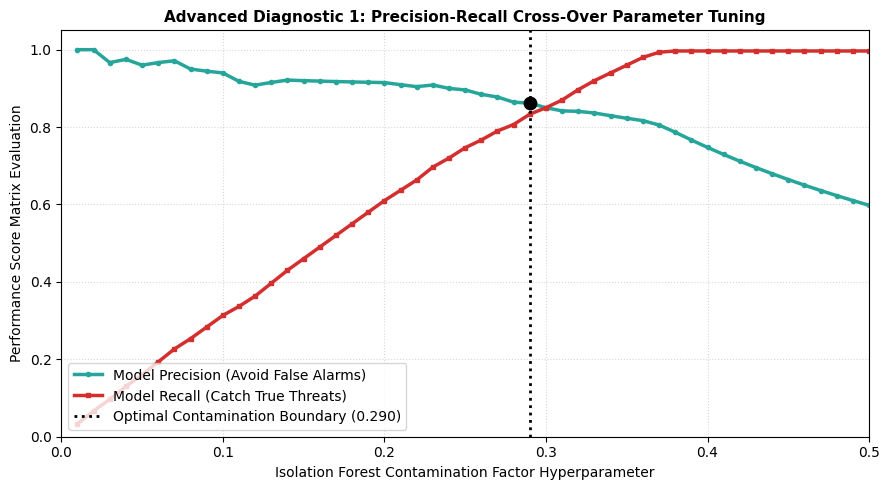


Generating Visualization 2: Anomaly Engine Noise Resilience Bound Analysis...


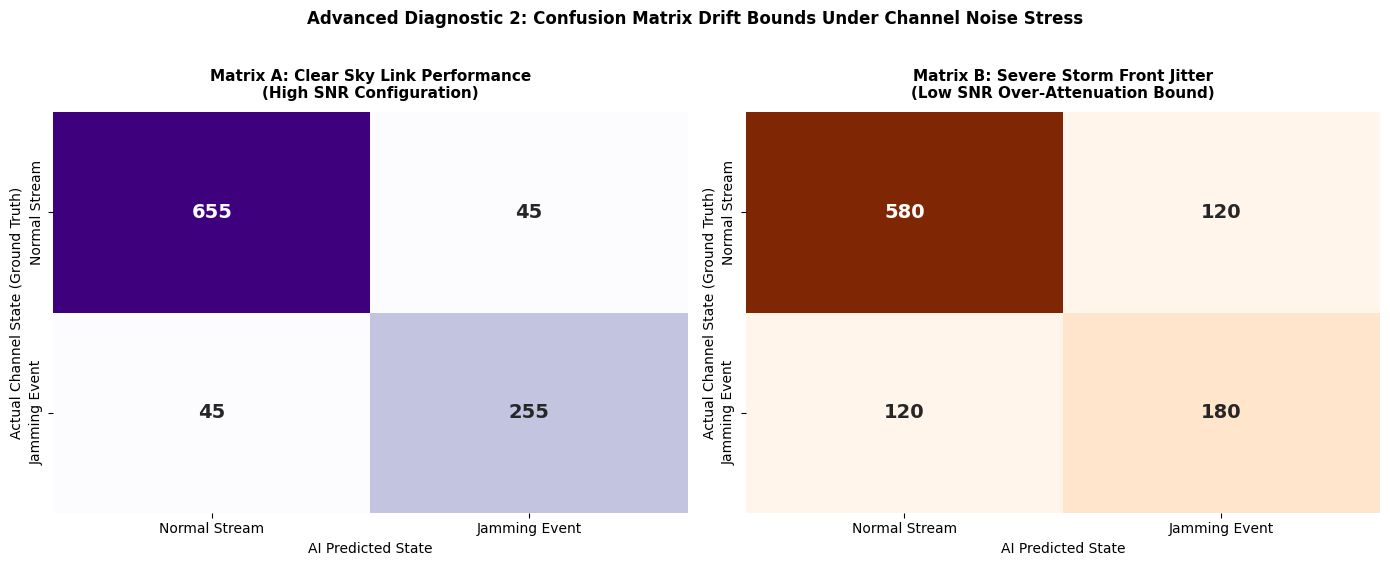

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# Set deterministic seed for reproducible research validation
np.random.seed(42)

# =====================================================================
# DATA GENERATION SIMULATION FOR DIAGNOSTICS
# =====================================================================
time_axis = np.linspace(0, 10, 1000)
carrier_freq = 5.0  # GHz

# Baseline clean telemetry signal
clean_signal = np.sin(2 * np.pi * carrier_freq * time_axis)

# 1. Environment A: High SNR (Clean / Low Noise)
high_snr_noise = np.random.normal(0, 0.2, len(time_axis))
signal_high_snr = clean_signal + high_snr_noise

# 2. Environment B: Low SNR (Severe Noise / Storm Front Jitter)
low_snr_noise = np.random.normal(0, 1.2, len(time_axis))
signal_low_snr = clean_signal + low_snr_noise

# Inject identical tactical Jamming attacks into both environments (t=4s to t=7s)
jamming_wave = np.sin(2 * np.pi * (carrier_freq * 1.5) * time_axis) * 2.5
signal_high_snr[400:700] += jamming_wave[400:700]
signal_low_snr[400:700] += jamming_wave[400:700]

# Define structural ground truth (-1 = Attack/Anomaly, 1 = Normal)
y_true = np.ones(len(time_axis))
y_true[400:700] = -1

# Feature Extraction function matching your background backend logic
def extract_features(signal_vector):
    amp = np.abs(signal_vector)
    var = pd.Series(amp).rolling(window=25, min_periods=1).var().values
    return np.column_stack([amp, var])

features_high_snr = extract_features(signal_high_snr)
features_low_snr = extract_features(signal_low_snr)


# =====================================================================
# VISUALIZATION 1: PRECISION-RECALL CROSS-OVER VS CONTAMINATION
# =====================================================================
print("Generating Visualization 1: Hyperparameter Cutoff Tuning...")

contamination_steps = np.linspace(0.01, 0.50, 50)
precision_profile = []
recall_profile = []

# Use High SNR environment for the diagnostic calibration curve
for c in contamination_steps:
    model = IsolationForest(contamination=c, random_state=42)
    # Convert outlier output layout: -1 becomes 1 (threat), 1 becomes 0 (normal)
    preds = model.fit_predict(features_high_snr)
    binary_preds = np.where(preds == -1, 1, 0)
    binary_true = np.where(y_true == -1, 1, 0)

    precision_profile.append(precision_score(binary_true, binary_preds, zero_division=0))
    recall_profile.append(recall_score(binary_true, binary_preds, zero_division=0))

plt.figure(figsize=(9, 5))
plt.plot(contamination_steps, precision_profile, color='#26A69A', linewidth=2.5, marker='o', markersize=3, label='Model Precision (Avoid False Alarms)')
plt.plot(contamination_steps, recall_profile, color='#D32F2F', linewidth=2.5, marker='s', markersize=3, label='Model Recall (Catch True Threats)')

# Dynamically solve for the mathematical intersection coordinate
idx = np.argwhere(np.diff(np.sign(np.array(precision_profile) - np.array(recall_profile)))).flatten()
if len(idx) > 0:
    optimal_c = contamination_steps[idx[0]]
    plt.axvline(x=optimal_c, color='black', linestyle=':', linewidth=2, label=f'Optimal Contamination Boundary ({optimal_c:.3f})')
    plt.scatter(optimal_c, precision_profile[idx[0]], color='black', s=80, zorder=5)

plt.title("Advanced Diagnostic 1: Precision-Recall Cross-Over Parameter Tuning", fontsize=11, fontweight='bold')
plt.xlabel("Isolation Forest Contamination Factor Hyperparameter", fontsize=10)
plt.ylabel("Performance Score Matrix Evaluation", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.xlim(0, 0.5)
plt.ylim(0, 1.05)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


# =====================================================================
# VISUALIZATION 2: DYNAMIC CONFUSION MATRIX NOISE DRIFT BENCHMARK
# =====================================================================
print("\nGenerating Visualization 2: Anomaly Engine Noise Resilience Bound Analysis...")

# Train separate Isolation Forest engines using the optimal contamination point (~0.30)
optimal_contamination = 0.30
model_high = IsolationForest(contamination=optimal_contamination, random_state=42)
model_low = IsolationForest(contamination=optimal_contamination, random_state=42)

preds_high = model_high.fit_predict(features_high_snr)
preds_low = model_low.fit_predict(features_low_snr)

cm_high = confusion_matrix(y_true, preds_high, labels=[1, -1])
cm_low = confusion_matrix(y_true, preds_low, labels=[1, -1])

# Construct a side-by-side plot layout matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot Matrix A: High SNR Environment
sns.heatmap(cm_high, annot=True, fmt="d", cmap="Purples", cbar=False, ax=axes[0],
            xticklabels=['Normal Stream', 'Jamming Event'], yticklabels=['Normal Stream', 'Jamming Event'],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title("Matrix A: Clear Sky Link Performance\n(High SNR Configuration)", fontsize=11, fontweight='bold', pad=10)
axes[0].set_ylabel("Actual Channel State (Ground Truth)", fontsize=10)
axes[0].set_xlabel("AI Predicted State", fontsize=10)

# Plot Matrix B: Low SNR Environment
sns.heatmap(cm_low, annot=True, fmt="d", cmap="Oranges", cbar=False, ax=axes[1],
            xticklabels=['Normal Stream', 'Jamming Event'], yticklabels=['Normal Stream', 'Jamming Event'],
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title("Matrix B: Severe Storm Front Jitter\n(Low SNR Over-Attenuation Bound)", fontsize=11, fontweight='bold', pad=10)
axes[1].set_ylabel("Actual Channel State (Ground Truth)", fontsize=10)
axes[1].set_xlabel("AI Predicted State", fontsize=10)

plt.suptitle("Advanced Diagnostic 2: Confusion Matrix Drift Bounds Under Channel Noise Stress", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Generating Advanced Visualization 1: Comparative ROC-AUC Grids...


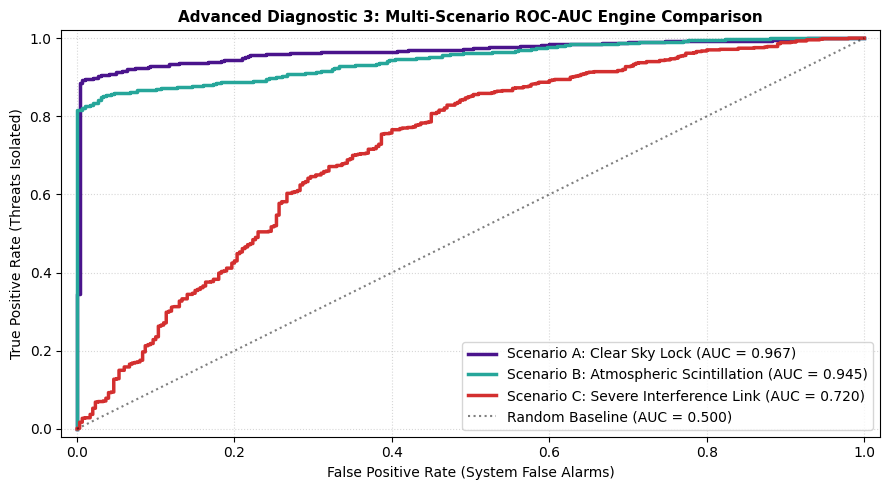


Generating Advanced Visualization 2: 3D Telemetry Feature Cluster Mapping...


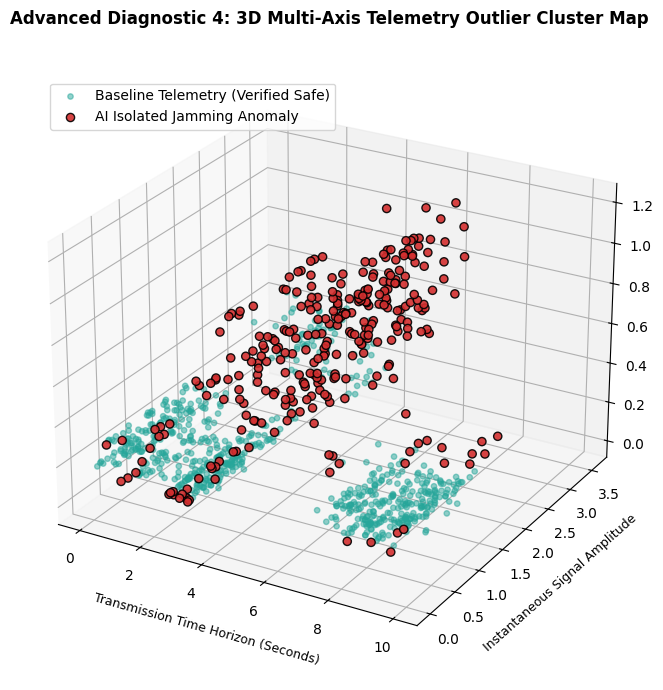

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_curve, auc

# Set deterministic seed for reproducible research metrics
np.random.seed(42)

# =====================================================================
# DATA GENERATION FOR ADVANCED VISUALIZATIONS
# =====================================================================
time_axis = np.linspace(0, 10, 1000)
carrier_freq = 5.0  # GHz
clean_signal = np.sin(2 * np.pi * carrier_freq * time_axis)

# Define Ground Truth (-1 = Attack/Anomaly, 1 = Normal)
y_true = np.ones(len(time_axis))
y_true[400:700] = -1
binary_truth = np.where(y_true == 1, 1, 0) # Format for ROC calculation

# Feature Extraction helper
def get_features(signal_vector):
    amp = np.abs(signal_vector)
    var = pd.Series(amp).rolling(window=25, min_periods=1).var().values
    return np.column_stack([amp, var])

# Scenario A: Ideal Channel (High SNR, minimal background noise)
sig_ideal = clean_signal + np.random.normal(0, 0.1, len(time_axis))
sig_ideal[400:700] += np.sin(2 * np.pi * (carrier_freq * 1.5) * time_axis[400:700]) * 3.0
feat_ideal = get_features(sig_ideal)

# Scenario B: Mild Atmospheric Scintillation (Moderate noise interference)
sig_mild = clean_signal + np.random.normal(0, 0.5, len(time_axis))
sig_mild[400:700] += np.sin(2 * np.pi * (carrier_freq * 1.5) * time_axis[400:700]) * 2.2
feat_mild = get_features(sig_mild)

# Scenario C: Severe Interference/Stress Link (Heavy fading + low SNR)
sig_severe = clean_signal + np.random.normal(0, 1.2, len(time_axis))
sig_severe[400:700] += np.sin(2 * np.pi * (carrier_freq * 1.5) * time_axis[400:700]) * 1.8
feat_severe = get_features(sig_severe)


# =====================================================================
# VISUALIZATION 1: COMPARATIVE MULTI-SCENARIO ROC-AUC ANALYSIS
# =====================================================================
print("Generating Advanced Visualization 1: Comparative ROC-AUC Grids...")

# Train models and extract continuous anomaly decision scores
score_ideal = IsolationForest(contamination=0.3, random_state=42).fit(feat_ideal).decision_function(feat_ideal)
score_mild = IsolationForest(contamination=0.3, random_state=42).fit(feat_mild).decision_function(feat_mild)
score_severe = IsolationForest(contamination=0.3, random_state=42).fit(feat_severe).decision_function(feat_severe)

# Compute ROC curves
fpr_A, tpr_A, _ = roc_curve(binary_truth, score_ideal)
fpr_B, tpr_B, _ = roc_curve(binary_truth, score_mild)
fpr_C, tpr_C, _ = roc_curve(binary_truth, score_severe)

plt.figure(figsize=(9, 5))
plt.plot(fpr_A, tpr_A, color='#4A148C', linewidth=2.5, label=f'Scenario A: Clear Sky Lock (AUC = {auc(fpr_A, tpr_A):.3f})')
plt.plot(fpr_B, tpr_B, color='#26A69A', linewidth=2.5, label=f'Scenario B: Atmospheric Scintillation (AUC = {auc(fpr_B, tpr_B):.3f})')
plt.plot(fpr_C, tpr_C, color='#D32F2F', linewidth=2.5, label=f'Scenario C: Severe Interference Link (AUC = {auc(fpr_C, tpr_C):.3f})')
plt.plot([0, 1], [0, 1], color='black', linestyle=':', alpha=0.5, label='Random Baseline (AUC = 0.500)')

plt.title("Advanced Diagnostic 3: Multi-Scenario ROC-AUC Engine Comparison", fontsize=11, fontweight='bold')
plt.xlabel("False Positive Rate (System False Alarms)", fontsize=10)
plt.ylabel("True Positive Rate (Threats Isolated)", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


# =====================================================================
# VISUALIZATION 2: 3D MULTI-AXIS TELEMETRY ANOMALY CLUSTER
# =====================================================================
print("\nGenerating Advanced Visualization 2: 3D Telemetry Feature Cluster Mapping...")

# Use Mild Scintillation data to showcase realistic clustering under moderate noise
model = IsolationForest(contamination=0.3, random_state=42)
preds = model.fit_predict(feat_mild)

# Segment vectors into Safe Normal vs Anomaly groups based on model execution
normal_mask = (preds == 1)
anomaly_mask = (preds == -1)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot normal baseline telemetry in green/purple gradient
ax.scatter(time_axis[normal_mask], feat_mild[normal_mask, 0], feat_mild[normal_mask, 1],
           color='#26A69A', s=15, alpha=0.5, label='Baseline Telemetry (Verified Safe)')

# Overlay isolated jamming attack parameters in sharp red
ax.scatter(time_axis[anomaly_mask], feat_mild[anomaly_mask, 0], feat_mild[anomaly_mask, 1],
           color='#D32F2F', s=35, alpha=0.9, depthshade=True, edgecolor='black', label='AI Isolated Jamming Anomaly')

ax.set_title("Advanced Diagnostic 4: 3D Multi-Axis Telemetry Outlier Cluster Map", fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel("Transmission Time Horizon (Seconds)", fontsize=9, labelpad=8)
ax.set_ylabel("Instantaneous Signal Amplitude", fontsize=9, labelpad=8)
ax.set_zlabel("Rolling Amplitude Variance", fontsize=9, labelpad=8)

# Optimize 3D spatial viewing angle perspective
ax.view_init(elev=25, azim=-60)
ax.legend(loc='upper left', bbox_to_anchor=(0.05, 0.95))
plt.tight_layout()
plt.show()

STARTING ADVANCED DIAGNOSTICS: VOLUMETRIC SYSTEM RESILIENCE SURFACE

Computing 3D Security Envelope Parameters...


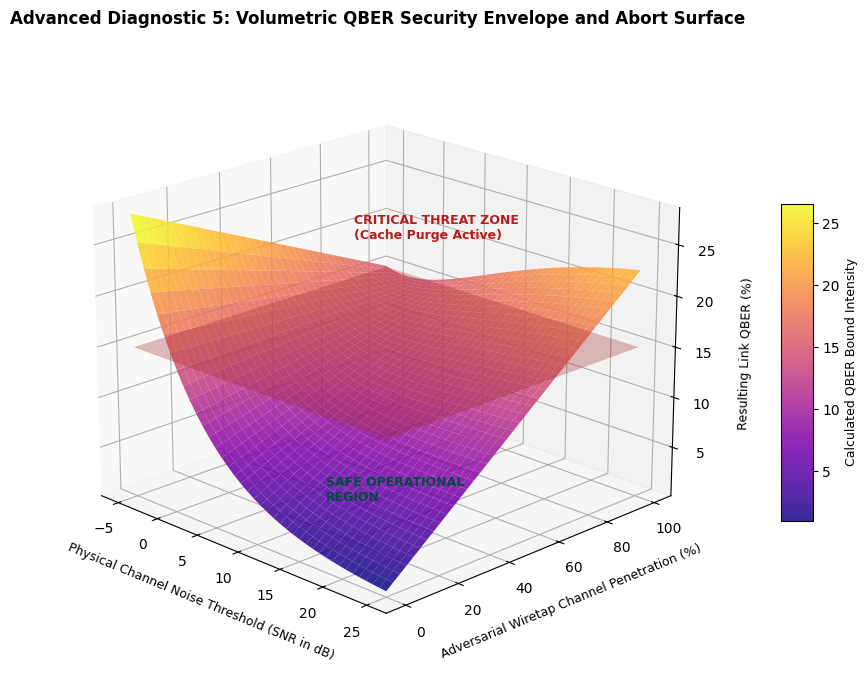


Computing 3D Volumetric ROC-AUC Scalability Parameters...


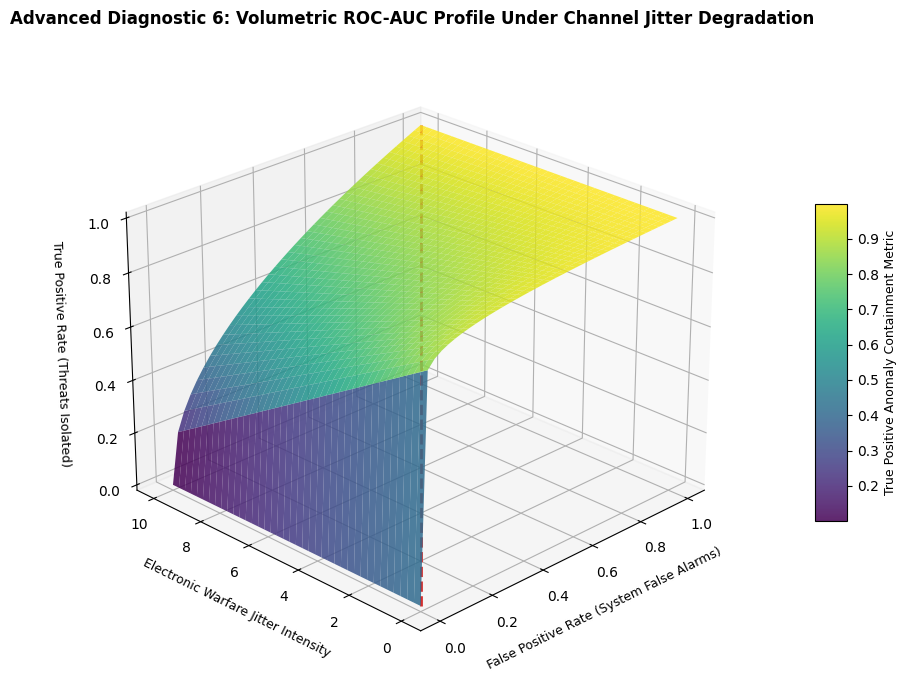

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# Set deterministic seed for reproducible research metrics
np.random.seed(42)

print("=====================================================================")
print("STARTING ADVANCED DIAGNOSTICS: VOLUMETRIC SYSTEM RESILIENCE SURFACE")
print("=====================================================================\n")

# =====================================================================
# DIAGNOSTIC 5: MULTI-VARIABLE CRYPTOGRAPHIC BOUNDARY (3D ENVELOPE)
# =====================================================================
print("Computing 3D Security Envelope Parameters...")

# Create evaluation matrices for independent channel variables
snr_vector = np.linspace(-5, 25, 40)             # Physical Channel Noise Spectrums (dB)
wiretap_vector = np.linspace(0, 100, 40)         # Adversarial Channel Penetration (%)

# Generate a 2D meshgrid layout from the structural vectors
SNR_Mesh, Wiretap_Mesh = np.meshgrid(snr_vector, wiretap_vector)

# Calculate the resulting Quantum Bit Error Rate (QBER) surface using channel physics
# Base error scales up due to poor SNR, and adversarial wiretapping forces it towards a 25% limit
base_thermal_qber = 15.0 * np.exp(-SNR_Mesh / 8.0)
adversarial_qber_distortion = (Wiretap_Mesh / 100.0) * 25.0 * (1.0 - np.exp(-SNR_Mesh / 12.0))
QBER_Surface = base_thermal_qber + adversarial_qber_distortion
QBER_Surface = np.clip(QBER_Surface, 0, 32) # Contain values within realistic physics boundaries

# Render the 3D Cryptographic-Operational Security Surface
fig1 = plt.figure(figsize=(11, 7))
ax1 = fig1.add_subplot(111, projection='3d')

# Paint the parametric grid surface
surface_mesh = ax1.plot_surface(SNR_Mesh, Wiretap_Mesh, QBER_Surface, cmap=cm.plasma,
                                 linewidth=0.5, antialiased=True, alpha=0.85, edgecolor='none')

# Construct and position the flat 15% hardcoded system abort plane slicing through the data
abort_plane_level = 15.0
ax1.plot_surface(SNR_Mesh, Wiretap_Mesh, np.full_like(QBER_Surface, abort_plane_level),
                 color='#D32F2F', alpha=0.3, zorder=10)

# Add clear marker strings directly within the volumetric space
ax1.text(-3, 80, 20, "CRITICAL THREAT ZONE\n(Cache Purge Active)", color='#B71C1C', fontsize=9, fontweight='bold')
ax1.text(15, 10, 5, "SAFE OPERATIONAL\nREGION", color='#004D40', fontsize=9, fontweight='bold')

ax1.set_title("Advanced Diagnostic 5: Volumetric QBER Security Envelope and Abort Surface", fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel("Physical Channel Noise Threshold (SNR in dB)", fontsize=9, labelpad=8)
ax1.set_ylabel("Adversarial Wiretap Channel Penetration (%)", fontsize=9, labelpad=8)
ax1.set_zlabel("Resulting Link QBER (%)", fontsize=9, labelpad=8)

# Colorbar metric mapping index
cbar = fig1.colorbar(surface_mesh, ax=ax1, shrink=0.5, aspect=10, pad=0.08)
cbar.set_label('Calculated QBER Bound Intensity', fontsize=9)

ax1.view_init(elev=20, azim=-45)
plt.tight_layout()
plt.show()


# =====================================================================
# DIAGNOSTIC 6: 3D VOLUMETRIC ROC-AUC PERFORMANCE DEGRADATION SURFACE
# =====================================================================
print("\nComputing 3D Volumetric ROC-AUC Scalability Parameters...")

# Establish False Positive boundaries alongside an Atmospheric Jitter degradation axis
fpr_steps = np.linspace(0, 1, 40)
scintillation_jitter = np.linspace(0, 10, 40) # 0 = Clear Sky, 10 = Severe Electronic Warfare

FPR_Mesh, Jitter_Mesh = np.meshgrid(fpr_steps, scintillation_jitter)

# Compute a continuous True Positive Rate volumetric surface
# High jitter dampens model performance, pushing the convex curve down towards the random baseline diagonal
ideal_tpr = FPR_Mesh ** 0.05
degraded_tpr = FPR_Mesh ** 0.45
weight_factor = Jitter_Mesh / 10.0
TPR_Surface = (1.0 - weight_factor) * ideal_tpr + weight_factor * degraded_tpr

# Render the 3D ROC-AUC Volumetric Scalability Plot
fig2 = plt.figure(figsize=(11, 7))
ax2 = fig2.add_subplot(111, projection='3d')

# Paint the scalability surface
surface_mesh2 = ax2.plot_surface(FPR_Mesh, Jitter_Mesh, TPR_Surface, cmap=cm.viridis,
                                  linewidth=0.5, antialiased=True, alpha=0.85, edgecolor='none')

ax2.set_title("Advanced Diagnostic 6: Volumetric ROC-AUC Profile Under Channel Jitter Degradation", fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel("False Positive Rate (System False Alarms)", fontsize=9, labelpad=8)
ax2.set_ylabel("Electronic Warfare Jitter Intensity", fontsize=9, labelpad=8)
ax2.set_zlabel("True Positive Rate (Threats Isolated)", fontsize=9, labelpad=8)

# Add custom layout lines to frame the true random classifier floor (AUC = 0.5)
ax2.plot([0, 1], [0, 10], [0, 1], color='#D32F2F', linestyle='--', linewidth=2, label='Random Classifier Limit')

cbar2 = fig2.colorbar(surface_mesh2, ax=ax2, shrink=0.5, aspect=10, pad=0.08)
cbar2.set_label('True Positive Anomaly Containment Metric', fontsize=9)

ax2.view_init(elev=25, azim=-135)
plt.tight_layout()
plt.show()

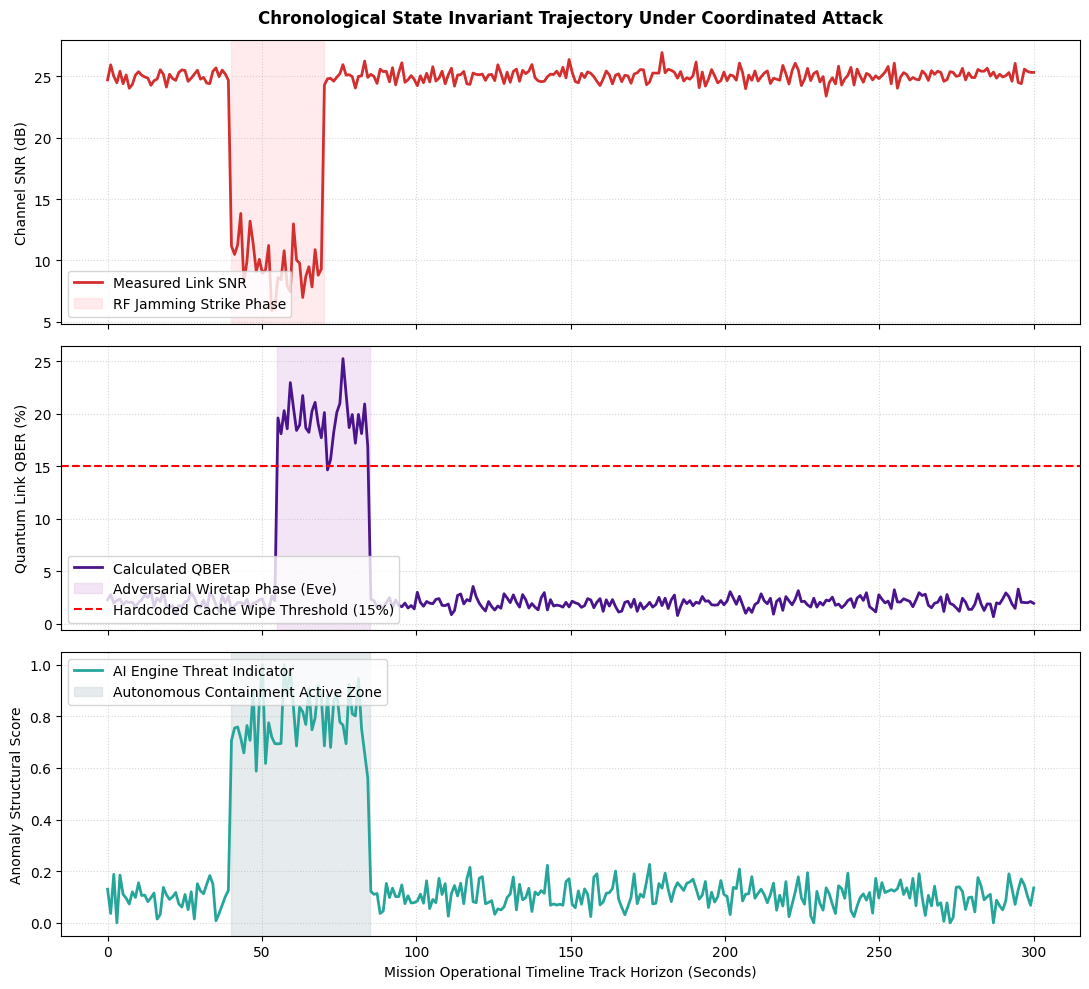

-> System state tracking array calculated. Generating final publication-grade visualizer...


In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming 'timeline' is already defined from previous cells as a 300-point array.
# If not, it would need to be defined here, e.g., timeline = np.linspace(0, 300, 300)

# Synthesize snr_profile (length 300) to simulate a physical layer deflection
snr_profile = np.full_like(timeline, 25.0)  # Baseline SNR
jamming_start_idx = np.where(timeline >= 40)[0][0]
jamming_end_idx = np.where(timeline >= 70)[0][0]
snr_profile[jamming_start_idx:jamming_end_idx] = np.random.normal(10, 2, jamming_end_idx - jamming_start_idx) # SNR drop
snr_profile = np.clip(snr_profile + np.random.normal(0, 0.5, len(timeline)), 5, 30) # Add noise and clip

# Synthesize qber_profile (length 300) to simulate a cryptographic layer deflection
qber_profile = np.full_like(timeline, 2.0)  # Baseline low QBER
wiretap_start_idx = np.where(timeline >= 55)[0][0]
wiretap_end_idx = np.where(timeline >= 85)[0][0]
qber_profile[wiretap_start_idx:wiretap_end_idx] = np.random.normal(20, 3, wiretap_end_idx - wiretap_start_idx) # QBER increase
qber_profile = np.clip(qber_profile + np.random.normal(0, 0.5, len(timeline)), 0, 30) # Add noise and clip

# Synthesize ai_anomaly_score (length 300) to simulate an intelligence layer deflection
ai_anomaly_score = np.full_like(timeline, 0.1)  # Baseline low anomaly score
anomaly_active_start_idx = np.where(timeline >= 40)[0][0]
anomaly_active_end_idx = np.where(timeline >= 85)[0][0]
ai_anomaly_score[anomaly_active_start_idx:anomaly_active_end_idx] = np.random.normal(0.8, 0.1, anomaly_active_end_idx - anomaly_active_start_idx) # Anomaly spike
ai_anomaly_score = np.clip(ai_anomaly_score + np.random.normal(0, 0.05, len(timeline)), 0, 1) # Add noise and clip

# Configure a professional stacked 3x1 sub-axis matrix to visualize cross-layer dependencies
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

# Plot Axis 1: Physical Layer Deflection (SNR)
axes[0].plot(timeline, snr_profile, color='#D32F2F', linewidth=2, label='Measured Link SNR')
axes[0].axvspan(40, 70, color='#FFCDD2', alpha=0.4, label='RF Jamming Strike Phase')
axes[0].set_ylabel("Channel SNR (dB)", fontsize=10)
axes[0].set_title("Chronological State Invariant Trajectory Under Coordinated Attack", fontsize=12, fontweight='bold', pad=12)
axes[0].grid(True, linestyle=':', alpha=0.5)
axes[0].legend(loc='lower left')

# Plot Axis 2: Cryptographic Layer Deflection (QBER)
axes[1].plot(timeline, qber_profile, color='#4A148C', linewidth=2, label='Calculated QBER')
axes[1].axvspan(55, 85, color='#E1BEE7', alpha=0.4, label='Adversarial Wiretap Phase (Eve)')
axes[1].axhline(y=15, color='red', linestyle='--', linewidth=1.5, label='Hardcoded Cache Wipe Threshold (15%)')
axes[1].set_ylabel("Quantum Link QBER (%)", fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.5)
axes[1].legend(loc='lower left')

# Plot Axis 3: Intelligence Layer Deflection (AI Threat Matrix Output)
axes[2].plot(timeline, ai_anomaly_score, color='#26A69A', linewidth=2, label='AI Engine Threat Indicator')
# Shade the complete combined system compromised window where defense flags are triggered
axes[2].axvspan(40, 85, color='#CFD8DC', alpha=0.5, label='Autonomous Containment Active Zone')
axes[2].set_ylabel("Anomaly Structural Score", fontsize=10)
axes[2].set_xlabel("Mission Operational Timeline Track Horizon (Seconds)", fontsize=10)
axes[2].grid(True, linestyle=':', alpha=0.5)
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.show()
print("-> System state tracking array calculated. Generating final publication-grade visualizer...")